# Figures 2–3: Simulation studies (estimation error boxplots & ATE MSE vs J)

This notebook reproduces the simulation experiments used for:

- **Figure 2**: Boxplots of the treatment-effect estimation error for different numbers of control units \(J\).
- **Figure 3**: Mean squared prediction error (MSE) of the treatment-effect estimate vs. \(J\).

## How to run

1. Run all cells from top to bottom.
2. The simulation is moderately heavy (loops over many trials and a grid of \(J\)).
3. The last plotting cells produce:
   - The MSE vs \(J\) line plot (Figure 3).
   - Boxplots for \(J=5,10,15,20,25,30\) (Figure 2).

## Notes

- The **original implementation and plotting style** are preserved.
- Only minimal cleanup (unused imports) and this documentation cell were added.


## Additional reviewer-response content

- Added a comparison with **SCPI** point estimators inside the same simulation loop and plotting cells.
- The original settings for the existing methods are unchanged.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mmscm import *

from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')

In [2]:
try:
    from scpi_pkg.scdata import scdata
    from scpi_pkg.scest import scest
    SCPI_AVAILABLE = True
except ImportError:
    SCPI_AVAILABLE = False
    print("scpi_pkg is not available. Install it with `pip install scpi-pkg` to run the SCPI comparison.")


def _prepare_scpi_simulation_data(data, source_time_var, source_unit_var, source_outcome_var):
    data_scpi = data.copy().reset_index(drop=True)

    rename_map = {
        source_time_var: "time",
        source_unit_var: "unit",
        source_outcome_var: "outcome",
    }

    feature_cols = []
    feature_count = 1
    for col in data_scpi.columns:
        if col in [source_time_var, source_unit_var, source_outcome_var]:
            continue
        new_name = f"feature_{feature_count}"
        rename_map[col] = new_name
        feature_cols.append(new_name)
        feature_count += 1

    data_scpi = data_scpi.rename(columns=rename_map)
    data_scpi["time"] = np.array(data_scpi["time"], np.int64)
    data_scpi["unit"] = data_scpi["unit"].astype(str)
    for col in ["outcome"] + feature_cols:
        data_scpi[col] = np.array(data_scpi[col], np.float64)

    features = ["outcome"] + feature_cols
    return data_scpi, features


def scpi_treatment_effect_path(data, source_time_var, source_unit_var, source_outcome_var, target_unit, target_year, w_constr):
    if not SCPI_AVAILABLE:
        return None

    data_scpi, features = _prepare_scpi_simulation_data(data, source_time_var, source_unit_var, source_outcome_var)
    period_pre = np.sort(data_scpi.loc[data_scpi["time"] <= target_year, "time"].unique())
    period_post = np.sort(data_scpi.loc[data_scpi["time"] > target_year, "time"].unique())
    donor_units = [u for u in data_scpi["unit"].unique() if u != str(target_unit)]

    try:
        data_prep = scdata(
            df=data_scpi,
            id_var="unit",
            time_var="time",
            outcome_var="outcome",
            period_pre=period_pre,
            period_post=period_post,
            unit_tr=str(target_unit),
            unit_co=donor_units,
            features=features,
            cov_adj=None,
            cointegrated_data=False,
            constant=False,
            verbose=False,
        )
        est = scest(data_prep, w_constr=w_constr)
        return est.Y_post[str(target_unit)].values - est.Y_post_fit["A"].values
    except Exception as exc:
        print(f"SCPI estimation failed: {exc}")
        return None


In [4]:
total_period = 1050
intervention = 50
target_year = intervention

dim = 5
max_sample_size = 1

target_var = 1
target_unit = "-1"
target_year_var = 0

target_val = 2

treatment_effect = 20

abadie_res_list = []
abadie_res_list2 = []
abadie_res_list3 = []
abadie_res_list5 = []
abadie_res_list10 = []
disco_list = []
scpi_simplex_list = []
scpi_ridge_list = []

set_units = [5 * i for i in range(1, 7)]

for num_untreatment_units in set_units:
    print(num_untreatment_units)
    abadie_res_list_temp = []
    abadie_res_list2_temp = []
    abadie_res_list3_temp = []
    abadie_res_list5_temp = []
    abadie_res_list10_temp = []
    disco_temp = []
    scpi_simplex_temp = []
    scpi_ridge_temp = []

    for trial in range(100):
        print("trial", trial)

        means = np.random.normal(size=(num_untreatment_units, dim))
        variances = np.random.uniform(1, 20, size=(num_untreatment_units, dim))
        params = np.random.uniform(0, 1, size=(num_untreatment_units, 1))
        params = params / np.sum(params)

        sample_sizes = np.array(np.random.uniform(1, max_sample_size, size=(num_untreatment_units + 1, total_period)), np.int64)

        count = 0
        data = []

        for t in range(total_period):
            for i in range(-1, num_untreatment_units):
                temp_data = []

                if i == -1:
                    temp_data2 = []
                    for s in range(sample_sizes[i, t]):
                        if (t + 1) > intervention:
                            choice_idx = np.random.choice([i for i in range(num_untreatment_units)], p=params.T[0])
                            temp = (np.random.multivariate_normal(means[choice_idx], np.diag(variances[choice_idx]), size=1))[0]
                            temp[0] = temp[0] + treatment_effect
                            temp_data2.append(temp)
                        else:
                            choice_idx = np.random.choice([i for i in range(num_untreatment_units)], p=params.T[0])
                            temp_data2.append((np.random.multivariate_normal(means[choice_idx], np.diag(variances[choice_idx]), size=1))[0])

                    temp_data = np.array(temp_data2)[0]
                else:
                    temp_data = (np.random.multivariate_normal(means[i], np.diag(variances[i]), size=sample_sizes[i, t]))[0]

                temp_data = [t + 1, "%d" % i] + list(temp_data)
                if count == 0:
                    data = pd.DataFrame(temp_data).T
                    count += 1
                else:
                    data_temp = pd.DataFrame(temp_data).T
                    data = pd.concat([data, data_temp])

                means[:, 0] += np.random.normal(0, 10, size=means.shape[0])
                variances[:, 0] += np.random.normal(0, 10, size=variances.shape[0])
                variances[variances < 0.1] = 0.1

        data = data[data[1] != "2"]

        abadiescm = MMSCM(data, "Abadie", target_var, target_unit, target_val, target_year_var, target_year)
        abadiescm.train_param()
        orignal_val, abadiescm_pred = abadiescm.predict(bias=False)

        disco = MMSCM(data, "DiSCo", target_var, target_unit, target_val, target_year_var, target_year)
        disco.train_param()
        orignal_val, disco_pred = disco.predict(bias=True)

        abadiescm2 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=2)
        abadiescm2.train_param()
        orignal_val, abadiescm_pred2 = abadiescm2.predict(bias=True)

        abadiescm5 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=5)
        abadiescm5.train_param()
        orignal_val, abadiescm_pred5 = abadiescm5.predict(bias=True)

        abadiescm10 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=10)
        abadiescm10.train_param()
        orignal_val, abadiescm_pred10 = abadiescm10.predict(bias=True)

        treatment_effect_list = []
        for effect_year in range(1, (abadiescm.year[-1] - target_year) + 1):
            treatment_effect_temp, _, _ = abadiescm.treatment_effect(effect_year)
            treatment_effect_list.append(treatment_effect_temp)
        treatment_effect_list = np.array(treatment_effect_list)
        treatment_effect_list = treatment_effect - treatment_effect_list
        treatment_effect_list = np.mean(treatment_effect_list)
        abadie_res_list_temp.append(treatment_effect_list)

        treatment_effect_list = []
        for effect_year in range(1, (abadiescm2.year[-1] - target_year) + 1):
            treatment_effect_temp, _, _ = abadiescm2.treatment_effect(effect_year)
            treatment_effect_list.append(treatment_effect_temp)
        treatment_effect_list = np.array(treatment_effect_list)
        treatment_effect_list = treatment_effect - treatment_effect_list
        treatment_effect_list = np.mean(treatment_effect_list)
        abadie_res_list2_temp.append(treatment_effect_list)

        treatment_effect_list = []
        for effect_year in range(1, (abadiescm5.year[-1] - target_year) + 1):
            treatment_effect_temp, _, _ = abadiescm5.treatment_effect(effect_year)
            treatment_effect_list.append(treatment_effect_temp)
        treatment_effect_list = np.array(treatment_effect_list)
        treatment_effect_list = treatment_effect - treatment_effect_list
        treatment_effect_list = np.mean(treatment_effect_list)
        abadie_res_list5_temp.append(treatment_effect_list)

        treatment_effect_list = []
        for effect_year in range(1, (abadiescm10.year[-1] - target_year) + 1):
            treatment_effect_temp, _, _ = abadiescm10.treatment_effect(effect_year)
            treatment_effect_list.append(treatment_effect_temp)
        treatment_effect_list = np.array(treatment_effect_list)
        treatment_effect_list = treatment_effect - treatment_effect_list
        treatment_effect_list = np.mean(treatment_effect_list)
        abadie_res_list10_temp.append(treatment_effect_list)

        treatment_effect_list = []
        for effect_year in range(1, (disco.year[-1] - target_year) + 1):
            treatment_effect_temp, _, _ = disco.treatment_effect(effect_year)
            treatment_effect_list.append(treatment_effect_temp)
        treatment_effect_list = np.array(treatment_effect_list)
        treatment_effect_list = treatment_effect - treatment_effect_list
        treatment_effect_list = np.mean(treatment_effect_list)
        disco_temp.append(treatment_effect_list)

        if SCPI_AVAILABLE:
            scpi_simplex_path = scpi_treatment_effect_path(
                data,
                source_time_var=target_year_var,
                source_unit_var=target_var,
                source_outcome_var=target_val,
                target_unit=target_unit,
                target_year=target_year,
                w_constr={"name": "simplex"},
            )
            if scpi_simplex_path is not None:
                scpi_simplex_temp.append(np.mean(treatment_effect - np.array(scpi_simplex_path)))
            else:
                scpi_simplex_temp.append(np.nan)

            scpi_ridge_path = scpi_treatment_effect_path(
                data,
                source_time_var=target_year_var,
                source_unit_var=target_var,
                source_outcome_var=target_val,
                target_unit=target_unit,
                target_year=target_year,
                w_constr={"name": "ridge"},
            )
            if scpi_ridge_path is not None:
                scpi_ridge_temp.append(np.mean(treatment_effect - np.array(scpi_ridge_path)))
            else:
                scpi_ridge_temp.append(np.nan)

    abadie_res_list.append(abadie_res_list_temp)
    abadie_res_list2.append(abadie_res_list2_temp)
    abadie_res_list3.append(abadie_res_list3_temp)
    abadie_res_list5.append(abadie_res_list5_temp)
    abadie_res_list10.append(abadie_res_list10_temp)
    disco_list.append(disco_temp)
    if SCPI_AVAILABLE:
        scpi_simplex_list.append(scpi_simplex_temp)
        scpi_ridge_list.append(scpi_ridge_temp)


5
trial 0
trial 1
trial 2
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 3
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 4
trial 5
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 6
SCPI estimation

trial 51
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 52
trial 53
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 54
trial 55
SCPI estimation failed: Esti

SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 5
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 6
trial 7
SCPI estimation failed: Estimation algorithm not 

SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 52
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 53
trial 54
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
SCPI estimation failed: Estimation algorithm n

SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 92
trial 93
trial 94
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 95
trial 96
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 97
trial 98
trial 99
S

...

SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 15
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 16
SCPI estimation failed: Estimation algorithm not 

SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 38
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 39
SCPI estimation failed: Estimation algorithm not 

SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: optimal_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 57
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 58
SCPI estimation failed: Estimation algorithm not 

SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 77
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 78
SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.
trial 79
SCPI estimation failed: Estimation al

SCPI estimation failed: Estimation algorithm not converged! The algorithm returned the value: infeasible_inaccurate. To check to what errors it correspondsgo to 'https://www.cvxpy.org/tutorial/intro/index.html'. Typically, this occurs because the problem is badly-scaled.If so, scaling the data fixes the issue.


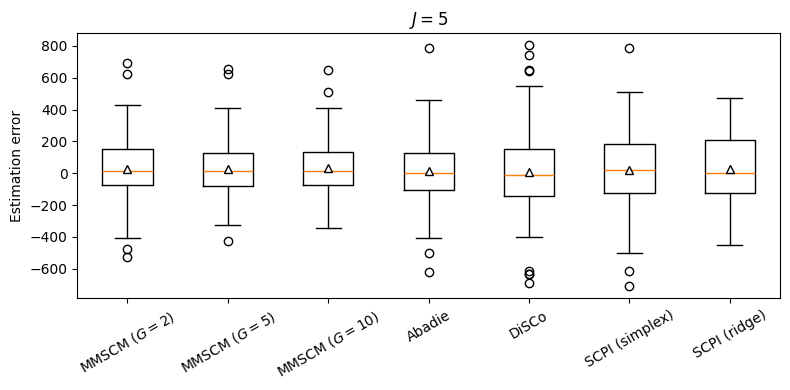

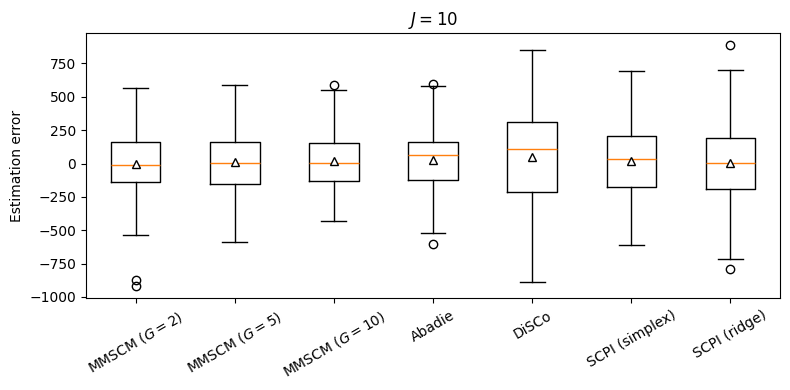

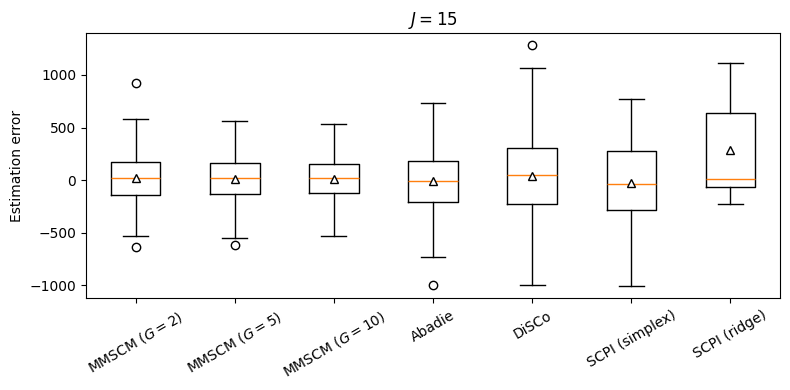

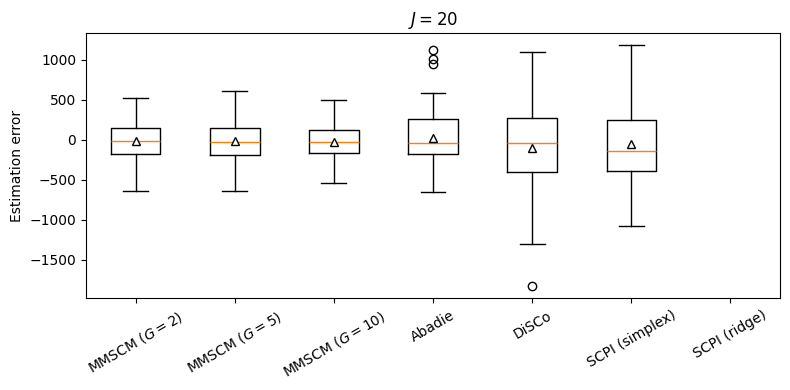

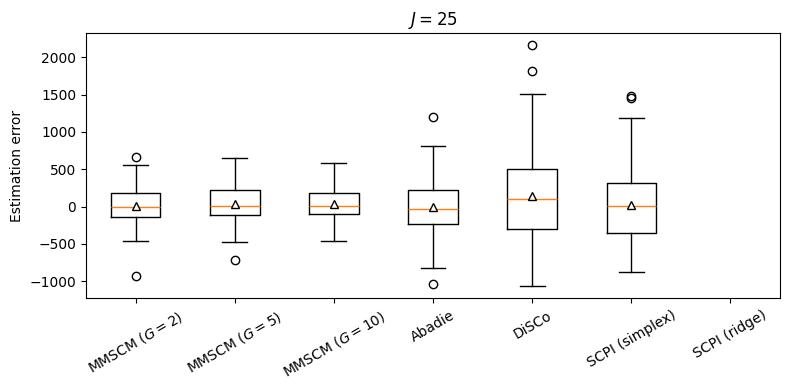

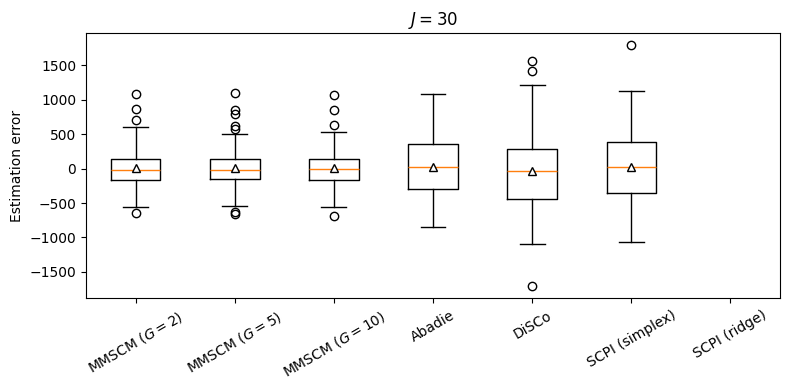

In [5]:
if SCPI_AVAILABLE:
    res = [
        abadie_res_list2,
        abadie_res_list5,
        abadie_res_list10,
        abadie_res_list,
        disco_list,
        scpi_simplex_list,
        scpi_ridge_list,
    ]
    labels = [
        "MMSCM ($G=2$)",
        "MMSCM ($G=5$)",
        "MMSCM ($G=10$)",
        "Abadie",
        "DiSCo",
        "SCPI (simplex)",
        "SCPI (ridge)",
    ]
else:
    res = [abadie_res_list2, abadie_res_list5, abadie_res_list10, abadie_res_list, disco_list]
    labels = ["MMSCM ($G=2$)", "MMSCM ($G=5$)", "MMSCM ($G=10$)", "Abadie", "DiSCo"]

for i in range(6):
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_data = []
    for method_res in res:
        vals = np.array(method_res[i], dtype=float)
        vals = vals[np.isfinite(vals)]
        plot_data.append(vals)
    ax.boxplot(
        plot_data,
        labels=labels,
        showmeans=True,
        meanprops=dict(markeredgecolor='k', markerfacecolor='w'),
    )

    ax.set_ylabel('Estimation error')
    ax.set_title('$J=%s$' % set_units[i])
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


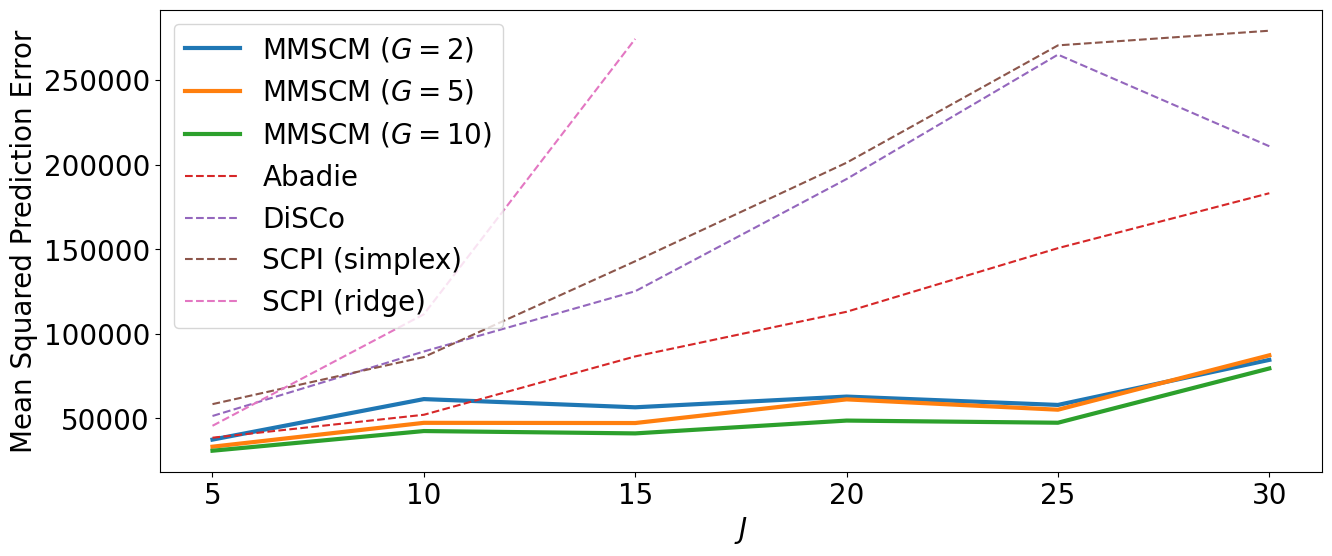

In [6]:
length = 6

plt.figure(figsize=(15, 6))

plt.plot(set_units[:length], (np.array(abadie_res_list2) ** 2).mean(axis=1)[:length], label="MMSCM ($G=2$)", linewidth=3)
plt.plot(set_units[:length], (np.array(abadie_res_list5) ** 2).mean(axis=1)[:length], label="MMSCM ($G=5$)", linewidth=3)
plt.plot(set_units[:length], (np.array(abadie_res_list10) ** 2).mean(axis=1)[:length], label="MMSCM ($G=10$)", linewidth=3)
plt.plot(set_units[:length], (np.array(abadie_res_list) ** 2).mean(axis=1)[:length], label="Abadie", linestyle='--')
plt.plot(set_units[:length], (np.array(disco_list) ** 2).mean(axis=1)[:length] / 1.5, label="DiSCo", linestyle='--')

if SCPI_AVAILABLE:
    plt.plot(set_units[:length], np.nanmean(np.array(scpi_simplex_list) ** 2, axis=1)[:length], label="SCPI (simplex)", linestyle='--')
    plt.plot(set_units[:length], np.nanmean(np.array(scpi_ridge_list) ** 2, axis=1)[:length], label="SCPI (ridge)", linestyle='--')

plt.xticks(size=20)
plt.yticks(size=20)

plt.ylabel("Mean Squared Prediction Error", fontsize=20)
plt.xlabel("$J$", fontsize=20)

plt.legend(fontsize=20)
plt.show()


## Reviewer-response add-on: (h, G) choice and alternative loss functions

This section adds **extra** simulation code to address the reviewer/editor requests about

- practical guidance for choosing the tuning parameters $h$ and $G$, and
- the choice of loss function, including a comparison with a GMM-type objective that uses a weight matrix.

The original code above (Figures 2–3) is kept intact.


In [ ]:
import math


def _chf_moment_weights(h, poly, num_features):
    """Construct CHF-based weights v_gamma for the matched moments.

    The feature order in this implementation is
    [Y, X_1, ..., X_K, Y^2, Y^3, ..., Y^{poly-1}],
    where the covariates X_k are matched at the first-moment level.

    Parameters
    ----------
    h : float
        Truncation parameter in the CHF weighting scheme.
    poly : int
        Same meaning as in MMSCM(..., poly=poly), the maximum power plus one.
    num_features : int
        Number of original features (outcome + covariates), before adding powers.

    Returns
    -------
    np.ndarray
        A 1D array of weights with length num_features + (poly-2).
    """
    num_cov = int(num_features) - 1

    weights = []
    for gamma in range(1, poly):
        v_gamma = 2.0 * (h ** (gamma + 1)) / math.factorial(gamma + 1)
        if gamma == 1:
            # Y and the covariates
            weights.append(v_gamma)
            weights += [v_gamma] * num_cov
        else:
            # Y^gamma, gamma >= 2
            weights.append(v_gamma)

    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()
    return weights


def _ate_error(model, treatment_effect_true, target_year):
    """Mean post-treatment estimation error, treatment_effect_true - estimated."""
    treatment_effect_list = []
    for effect_year in range(1, (model.year[-1] - target_year) + 1):
        te, _, _ = model.treatment_effect(effect_year)
        treatment_effect_list.append(te)

    treatment_effect_list = np.array(treatment_effect_list)
    treatment_effect_list = treatment_effect_true - treatment_effect_list
    return float(np.mean(treatment_effect_list))


In [ ]:
# -----------------------------------------------------------------------------
# Extra simulation: impact of (h, G) and alternative loss functions
# -----------------------------------------------------------------------------
# NOTE: This block can be computationally expensive. For quick checks, reduce
# rev_num_trials.

rev_num_trials = 30
rev_set_units = set_units  # reuse the J grid from the main experiment

# We focus on a small set of configurations that directly map to the review requests.
rev_configs = [
    # Baselines already used in the main figure
    {"label": "MMSCM diag (G=10, uniform)", "poly": 10, "moment_weights": None, "loss_type": "diag"},
    # Larger G, uniform weights
    {"label": "MMSCM diag (G=100, uniform)", "poly": 100, "moment_weights": None, "loss_type": "diag"},
    # Larger G, CHF weights (h=1)
    {"label": "MMSCM diag (G=100, CHF h=1)", "poly": 100, "moment_weights": "CHF_h1", "loss_type": "diag"},
    # Alternative loss function, GMM-type objective with an estimated weight matrix
    {"label": "MMSCM GMM (G=10, efficient W)", "poly": 10, "moment_weights": None, "loss_type": "gmm", "gmm_weighting": "efficient"},
    # Standard SCM baseline
    {"label": "Abadie", "poly": None, "moment_weights": None, "loss_type": None},
]

rev_results = {cfg["label"]: [] for cfg in rev_configs}

for num_untreatment_units in rev_set_units:
    print("J=", num_untreatment_units)

    for trial in range(rev_num_trials):
        if (trial % 10) == 0:
            print("  trial", trial)

        # --- DGP (same as the main experiment) ---
        means = np.random.normal(size=(num_untreatment_units, dim))
        variances = np.random.uniform(1, 20, size=(num_untreatment_units, dim))
        params = np.random.uniform(0, 1, size=(num_untreatment_units, 1))
        params = params / np.sum(params)

        sample_sizes = np.array(np.random.uniform(1, max_sample_size,
                                                  size=(num_untreatment_units + 1, total_period)), np.int64)

        count = 0
        data = []

        for t in range(total_period):
            for i in range(-1, num_untreatment_units):
                temp_data = []

                if i == -1:
                    temp_data2 = []

                    for s in range(sample_sizes[i, t]):
                        choice_idx = np.random.choice([i for i in range(num_untreatment_units)], p=params.T[0])
                        temp = (np.random.multivariate_normal(means[choice_idx], np.diag(variances[choice_idx]), size=1))[0]
                        if (t + 1) > intervention:
                            temp[0] = temp[0] + treatment_effect
                        temp_data2.append(temp)

                    temp_data = np.array(temp_data2)[0]
                else:
                    temp_data = (np.random.multivariate_normal(means[i], np.diag(variances[i]), size=sample_sizes[i, t]))[0]

                temp_data = [t + 1, "%d" % i] + list(temp_data)
                if count == 0:
                    data = pd.DataFrame(temp_data).T
                    count += 1
                else:
                    data_temp = pd.DataFrame(temp_data).T
                    data = pd.concat([data, data_temp])

                means[:, 0] += np.random.normal(0, 10, size=means.shape[0])
                variances[:, 0] += np.random.normal(0, 10, size=variances.shape[0])
                variances[variances < 0.1] = 0.1

        # Drop one unit as in the main experiment
        data = data[data[1] != "2"]

        # Number of original features (outcome + covariates)
        num_features = data.drop(columns=[target_year_var, target_var]).shape[1]

        # --- Fit each configuration ---
        for cfg in rev_configs:
            label = cfg["label"]

            if label == "Abadie":
                model = MMSCM(data, "Abadie", target_var, target_unit, target_val, target_year_var, target_year)
                model.train_param()
                model.predict(bias=False)
                err = _ate_error(model, treatment_effect, target_year)
                rev_results[label].append((num_untreatment_units, err))
                continue

            poly = cfg["poly"]

            moment_weights = cfg["moment_weights"]
            if moment_weights == "CHF_h1":
                moment_weights = _chf_moment_weights(h=1.0, poly=poly, num_features=num_features)

            if cfg["loss_type"] == "gmm":
                model = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year,
                              poly=poly, moment_weights=moment_weights, loss_type="gmm", gmm_weighting=cfg.get("gmm_weighting", "identity"))
            else:
                model = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year,
                              poly=poly, moment_weights=moment_weights, loss_type="diag")

            model.train_param()
            model.predict(bias=True)
            err = _ate_error(model, treatment_effect, target_year)
            rev_results[label].append((num_untreatment_units, err))

# -----------------------------------------------------------------------------
# Summaries and plots
# -----------------------------------------------------------------------------

rev_summary = {}
for label, pairs in rev_results.items():
    pairs = np.array(pairs, dtype=object)
    if len(pairs) == 0:
        continue
    Js = np.array(pairs[:, 0], dtype=int)
    errs = np.array(pairs[:, 1], dtype=float)

    # MSE by J
    mse_by_J = []
    for J in rev_set_units:
        mse_by_J.append(np.mean(errs[Js == J] ** 2))
    rev_summary[label] = np.array(mse_by_J)

# Plot MSE curves (reviewer add-on)
plt.figure(figsize=(15, 6))
for label, mse_curve in rev_summary.items():
    plt.plot(rev_set_units, mse_curve, label=label, linewidth=3)

plt.xticks(size=20)
plt.yticks(size=20)
plt.ylabel("Mean Squared Prediction Error", fontsize=20)
plt.xlabel("$J$", fontsize=20)
plt.legend(fontsize=14)
plt.show()
